In [1]:
import os
import numpy as np
import librosa
import joblib
import tensorflow as tf
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

DATA_PATH = "../datasets/ravdess/audio_speech_actors_01-24"

sr = 22050
n_mels = 128
duration = 3
max_len = sr * duration

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "anxious",
    "07": "frustrated",
    "08": "surprised"
}

X = []
y = []

print("Processing audio files...")

for root, dirs, files in os.walk(DATA_PATH):
    for file in tqdm(files):
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            emotion_code = file.split("-")[2]
            emotion = emotion_map[emotion_code]

            signal, _ = librosa.load(file_path, sr=sr)

            # Fix duration
            if len(signal) < max_len:
                signal = np.pad(signal, (0, max_len - len(signal)))
            else:
                signal = signal[:max_len]

            # Generate Mel Spectrogram
            mel_spec = librosa.feature.melspectrogram(
                y=signal,
                sr=sr,
                n_mels=n_mels
            )

            mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

            # Fix time dimension to 128
            if mel_spec.shape[1] < 128:
                pad_width = 128 - mel_spec.shape[1]
                mel_spec = np.pad(mel_spec, ((0,0),(0,pad_width)))
            else:
                mel_spec = mel_spec[:, :128]

            X.append(mel_spec)
            y.append(emotion)

X = np.array(X)
X = X[..., np.newaxis]


# Globel Normalization
X = X.astype("float32")

X_min = np.min(X)
X_max = np.max(X)

X = (X - X_min) / (X_max - X_min + 1e-6)


# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)


Processing audio files...


0it [00:00, ?it/s]
  0%|          | 0/60 [00:00<?, ?it/s]c:\Users\User\Documents\Work Projects\New folder (2)\MoodSync-App\ml\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 60/60 [00:00<00:00, 106.88it/s]


In [2]:
print(np.min(X), np.max(X))
print("Min:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())

0.0 1.0
Min: 0.0
Max: 1.0
Mean: 0.24540815


In [3]:
os.makedirs("../preprocessed_audio_data", exist_ok=True)

np.save("../preprocessed_audio_data/X.npy", X)
np.save("../preprocessed_audio_data/y.npy", y_categorical)
np.save("../preprocessed_audio_data/label_classes.npy", le.classes_)

joblib.dump(le, "../preprocessed_audio_data/label_encoder.pkl")

print("Preprocessing complete!")
print("Shape:", X.shape)
print("Classes:", le.classes_)

Preprocessing complete!
Shape: (1440, 128, 128, 1)
Classes: ['angry' 'anxious' 'calm' 'frustrated' 'happy' 'neutral' 'sad' 'surprised']


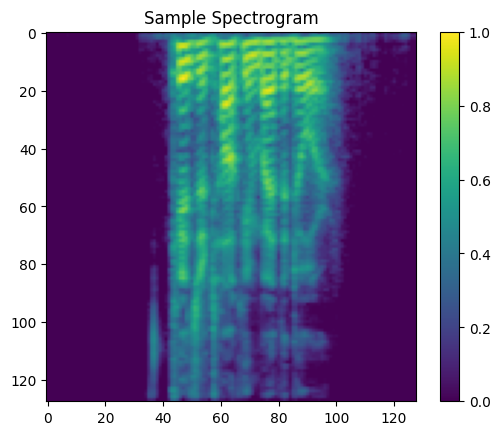

In [4]:
import matplotlib.pyplot as plt

plt.imshow(X[0].squeeze(), cmap='viridis')
plt.title("Sample Spectrogram")
plt.colorbar()
plt.show()